# Monte Carlo Simulation V2
Enhanced simulation using ELO ratings and player strength features

In [1]:
import pandas as pd
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

BASE = r'C:\Project\FIFA_World_Cup_2026'

# Load V2 models
with open(os.path.join(BASE, 'Model_Training', 'xgb_model_v2.pkl'), 'rb') as f:
    xgb_model = pickle.load(f)

with open(os.path.join(BASE, 'Model_Training', 'label_encoder_v2.pkl'), 'rb') as f:
    le = pickle.load(f)

# Load data
features_df = pd.read_csv(os.path.join(BASE, 'Feature_Engineering', 'features_v2.csv'))
elo = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'elo_cleaned.csv'))
player_strength = pd.read_csv(os.path.join(BASE, 'Cleaned_Data', 'player_strength.csv'))

print("All loaded!")

All loaded!


## 2026 World Cup Teams

In [15]:
wc_teams = [
    # CONMEBOL (6)
    'Brazil', 'Argentina', 'Uruguay', 'Colombia', 'Ecuador', 'Paraguay',
    # UEFA (16)
    'France', 'Spain', 'England', 'Germany', 'Portugal', 'Netherlands',
    'Belgium', 'Croatia', 'Switzerland', 'Austria', 'Norway', 'Scotland',
    'Sweden', 'Turkey', 'Bosnia and Herzegovina', 'Czechia',
    # AFC (9)
    'Japan', 'South Korea', 'Australia', 'Iran', 'Saudi Arabia', 'Qatar',
    'Uzbekistan', 'Jordan', 'Iraq',
    # CAF (10)
    'Morocco', 'Senegal', 'Egypt', 'Ghana', 'Algeria', 'Tunisia',
    'Ivory Coast', 'South Africa', 'Cape Verde', 'DR Congo',
    # CONCACAF (6)
    'United States', 'Mexico', 'Canada', 'Panama', 'Curacao', 'Haiti',
    # OFC (1)
    'New Zealand'
]

print(f"Total teams: {len(wc_teams)}")

## Build Team Profiles with ELO and Player Strength

In [5]:
elo_lookup = elo.set_index('team')['elo_rating'].to_dict()
elo_wr_lookup = elo.set_index('team')['elo_win_rate'].to_dict()
ps = player_strength.set_index('team')

def get_player_stat(team, col, default=0):
    try:
        val = ps.loc[team, col]
        return val if not pd.isna(val) else default
    except:
        return default

def get_team_stats(team, df, n=20):
    team_matches = df[
        (df['home_team'] == team) | (df['away_team'] == team)
    ].tail(n)
    
    if len(team_matches) == 0:
        return {'form': 0.5, 'avg_scored': 1.0, 'avg_conceded': 1.0}
    
    wins, scored, conceded = 0, [], []
    for _, row in team_matches.iterrows():
        if row['home_team'] == team:
            scored.append(row['home_avg_scored'])
            conceded.append(row['home_avg_conceded'])
            if row['result'] == 1:
                wins += 1
        else:
            scored.append(row['away_avg_scored'])
            conceded.append(row['away_avg_conceded'])
            if row['result'] == -1:
                wins += 1
    
    return {
        'form': wins / len(team_matches),
        'avg_scored': np.mean(scored),
        'avg_conceded': np.mean(conceded)
    }

team_stats = {team: get_team_stats(team, features_df) for team in wc_teams}
print("Team profiles built!")
print("\nExample - France:", team_stats['France'])
print("Example - Brazil:", team_stats['Brazil'])

Team profiles built!

Example - France: {'form': 0.65, 'avg_scored': np.float64(1.72), 'avg_conceded': np.float64(0.9650000000000002)}
Example - Brazil: {'form': 0.55, 'avg_scored': np.float64(1.5550000000000002), 'avg_conceded': np.float64(0.8950000000000001)}


## Match Prediction Function V2

In [6]:
feature_cols = [
    'home_form', 'away_form', 'form_diff',
    'home_avg_scored', 'home_avg_conceded',
    'away_avg_scored', 'away_avg_conceded',
    'goal_diff', 'is_neutral',
    'home_elo', 'away_elo', 'elo_diff',
    'home_elo_winrate', 'away_elo_winrate',
    'home_attack', 'away_attack', 'attack_diff',
    'home_defense', 'away_defense', 'defense_diff',
    'home_mid', 'away_mid'
]

def predict_match_v2(home_team, away_team, is_neutral=1):
    home = team_stats[home_team]
    away = team_stats[away_team]
    
    home_elo = elo_lookup.get(home_team, 1500)
    away_elo = elo_lookup.get(away_team, 1500)
    
    features = np.array([[
        home['form'],
        away['form'],
        home['form'] - away['form'],
        home['avg_scored'],
        home['avg_conceded'],
        away['avg_scored'],
        away['avg_conceded'],
        home['avg_scored'] - away['avg_scored'],
        is_neutral,
        home_elo,
        away_elo,
        home_elo - away_elo,
        elo_wr_lookup.get(home_team, 0.5),
        elo_wr_lookup.get(away_team, 0.5),
        get_player_stat(home_team, 'attack_goals'),
        get_player_stat(away_team, 'attack_goals'),
        get_player_stat(home_team, 'attack_goals') - get_player_stat(away_team, 'attack_goals'),
        get_player_stat(home_team, 'def_tackles'),
        get_player_stat(away_team, 'def_tackles'),
        get_player_stat(home_team, 'def_tackles') - get_player_stat(away_team, 'def_tackles'),
        get_player_stat(home_team, 'mid_tackles'),
        get_player_stat(away_team, 'mid_tackles'),
    ]])
    
    probs = xgb_model.predict_proba(features)[0]
    
    # Add small randomness to simulate football unpredictability
    noise = np.random.dirichlet(np.ones(3) * 8)
    probs = 0.85 * probs + 0.15 * noise
    
    # No draws in knockout — pick winner
    if probs[2] > probs[0]:
        return home_team
    else:
        return away_team

print("V2 prediction function ready!")

V2 prediction function ready!


## Run Monte Carlo Simulation V2

In [7]:
def simulate_world_cup_v2(teams, n_simulations=10000):
    win_counts = {team: 0 for team in teams}
    
    for sim in range(n_simulations):
        remaining = teams.copy()
        np.random.shuffle(remaining)
        
        while len(remaining) > 1:
            next_round = []
            for i in range(0, len(remaining) - 1, 2):
                winner = predict_match_v2(remaining[i], remaining[i+1])
                next_round.append(winner)
            if len(remaining) % 2 == 1:
                next_round.append(remaining[-1])
            remaining = next_round
        
        win_counts[remaining[0]] += 1
        
        if (sim + 1) % 1000 == 0:
            print(f"Completed: {sim + 1}/10000 simulations")
    
    win_probs = {team: (count / n_simulations) * 100 
                 for team, count in win_counts.items()}
    return win_probs

print("Running 10,000 simulations...")
win_probs = simulate_world_cup_v2(wc_teams, n_simulations=10000)
print("\nDone!")

Running 10,000 simulations...
Completed: 1000/10000 simulations
Completed: 2000/10000 simulations
Completed: 3000/10000 simulations
Completed: 4000/10000 simulations
Completed: 5000/10000 simulations
Completed: 6000/10000 simulations
Completed: 7000/10000 simulations
Completed: 8000/10000 simulations
Completed: 9000/10000 simulations
Completed: 10000/10000 simulations

Done!


## Run Monte Carlo Simulation V2

## Results

In [11]:
results_df = pd.DataFrame(list(win_probs.items()),
                          columns=['Team', 'Win Probability (%)'])
results_df = results_df.sort_values('Win Probability (%)', ascending=False).reset_index(drop=True)
results_df['Rank'] = results_df.index + 1

print("TOP 20 PREDICTED WORLD CUP 2026 WINNERS (V2)")
print("=" * 50)
print(results_df.head(20).to_string(index=False))

TOP 20 PREDICTED WORLD CUP 2026 WINNERS (V2)
       Team  Win Probability (%)  Rank
     France                37.71     1
      Spain                27.86     2
  Argentina                23.05     3
      Japan                 9.40     4
     Brazil                 0.80     5
   Portugal                 0.43     6
    Ecuador                 0.21     7
    England                 0.14     8
Netherlands                 0.08     9
   Colombia                 0.07    10
 Uzbekistan                 0.07    11
    Senegal                 0.07    12
    Uruguay                 0.05    13
     Mexico                 0.03    14
      Egypt                 0.02    15
    Germany                 0.01    16
    Austria                 0.00    17
Switzerland                 0.00    18
    Croatia                 0.00    19
    Belgium                 0.00    20


## Visualise Results

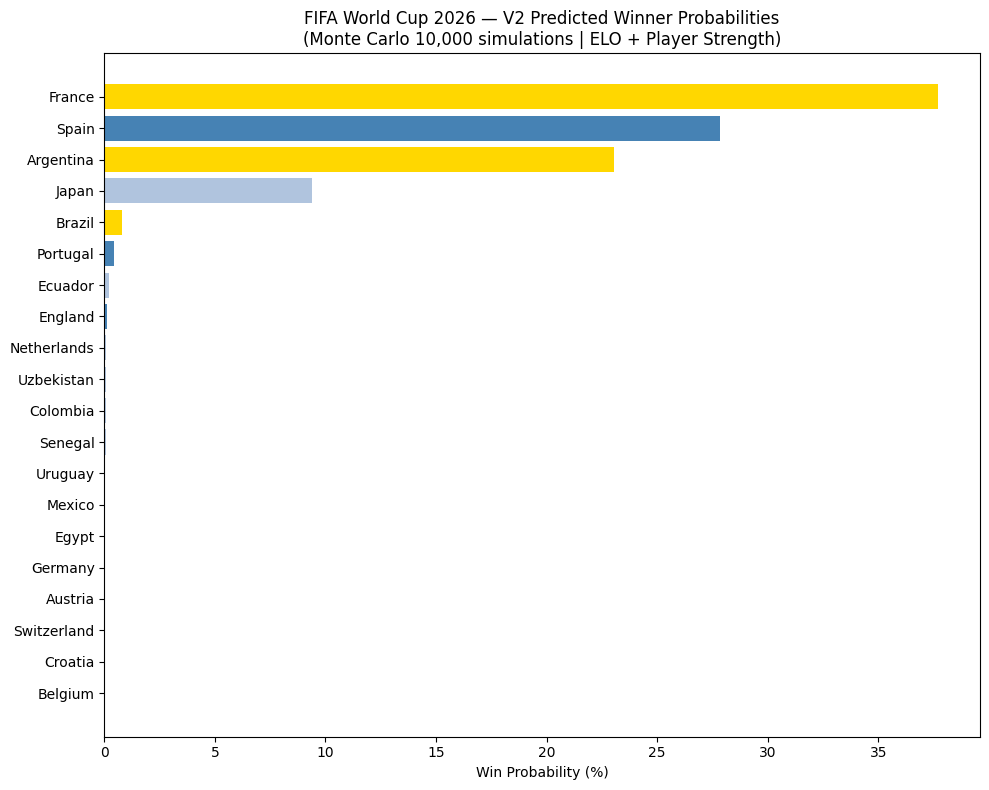

Saved!


In [12]:
top20 = results_df.head(20).sort_values('Win Probability (%)', ascending=True)

colors = []
for team in top20['Team']:
    if team in ['France', 'Brazil', 'Argentina']:
        colors.append('gold')
    elif team in ['England', 'Spain', 'Germany', 'Portugal']:
        colors.append('steelblue')
    else:
        colors.append('lightsteelblue')

plt.figure(figsize=(10, 8))
plt.barh(top20['Team'], top20['Win Probability (%)'], color=colors)
plt.xlabel('Win Probability (%)')
plt.title('FIFA World Cup 2026 — V2 Predicted Winner Probabilities\n(Monte Carlo 10,000 simulations | ELO + Player Strength)')
plt.tight_layout()
plt.savefig(os.path.join(BASE, 'Monte_Carlo_Simulation', 'wc2026_predictions_v2.png'))
plt.show()

results_df.to_csv(os.path.join(BASE, 'Monte_Carlo_Simulation', 'predictions_v2.csv'), index=False)
print("Saved!")

In [13]:
# Check which WC teams are missing from our data
for team in wc_teams:
    matches = features_df[
        (features_df['home_team'] == team) | 
        (features_df['away_team'] == team)
    ]
    if len(matches) == 0:
        print(f"MISSING: {team}")

MISSING: Czechia
MISSING: Curacao


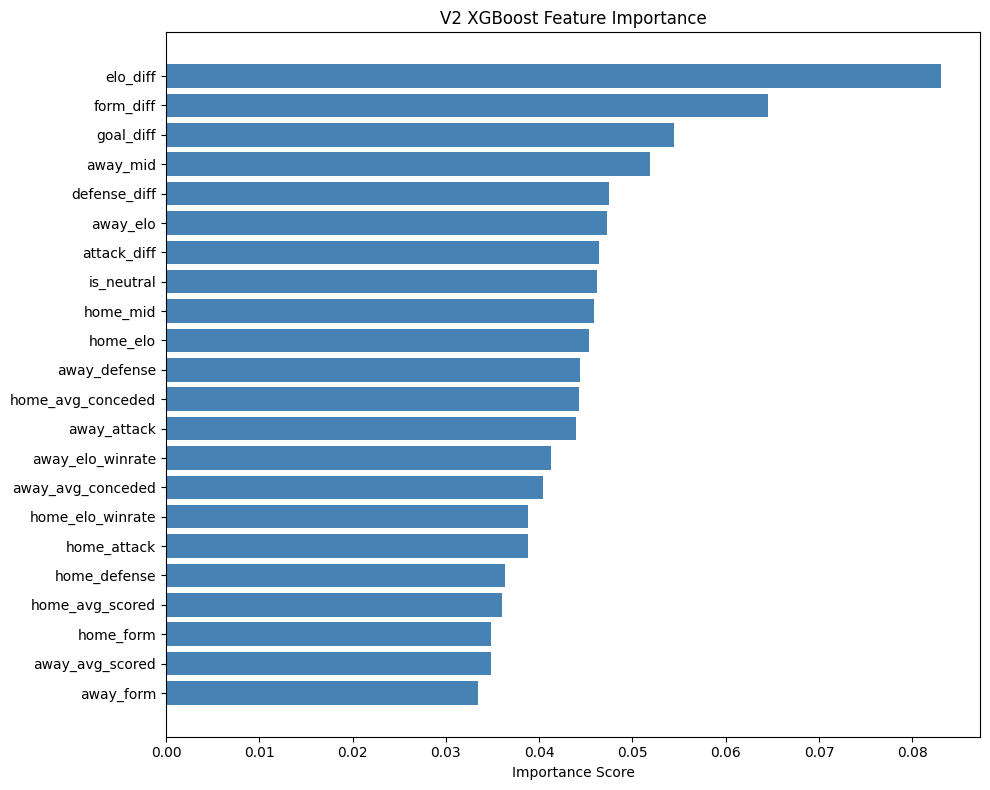


Top 5 most important features:
     feature  importance
defense_diff    0.047537
    away_mid    0.051868
   goal_diff    0.054406
   form_diff    0.064513
    elo_diff    0.083094


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

feature_cols = [
    'home_form', 'away_form', 'form_diff',
    'home_avg_scored', 'home_avg_conceded',
    'away_avg_scored', 'away_avg_conceded',
    'goal_diff', 'is_neutral',
    'home_elo', 'away_elo', 'elo_diff',
    'home_elo_winrate', 'away_elo_winrate',
    'home_attack', 'away_attack', 'attack_diff',
    'home_defense', 'away_defense', 'defense_diff',
    'home_mid', 'away_mid'
]

importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(importance['feature'], importance['importance'], color='steelblue')
plt.title('V2 XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importance.tail(5)[['feature', 'importance']].to_string(index=False))